In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy

# Neibourhood census dataset EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Blogathon 2025/census.csv")
df

Mounted at /content/drive


,Neighbourhood Number,1,2,3,4,5,6,7,8,9,...,165,166,167,168,169,170,171,172,173,174
0,Neighbourhood Name,West Humber-Clairville,Mount Olive-Silverstone-Jamestown,Thistletown-Beaumond Heights,Rexdale-Kipling,Elms-Old Rexdale,Kingsview Village-The Westway,Willowridge-Martingrove-Richview,Humber Heights-Westmount,Edenbridge-Humber Valley,...,Harbourfront-CityPlace,St Lawrence-East Bayfront-The Islands,Church-Wellesley,Downtown Yonge East,Bay-Cloverhill,Yonge-Bay Corridor,Junction-Wallace Emerson,Dovercourt Village,North Toronto,South Eglinton-Davisville
1,TSNS 2020 Designation,Not an NIA or Emerging Neighbourhood,Neighbourhood Improvement Area,Neighbourhood Improvement Area,Not an NIA or Emerging Neighbourhood,Neighbourhood Improvement Area,Neighbourhood Improvement Area,Not an NIA or Emerging Neighbourhood,Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,...,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood
2,Total - Age groups of the population - 25% sam...,33300,31345,9850,10375,9355,22005,22445,10005,15190,...,28135,31285,22320,17700,16670,12645,23180,12380,15885,22735
3,0 to 14 years,4295,5690,1495,1575,1610,3915,3500,1370,2070,...,2065,2285,895,1055,745,970,3075,1365,1315,2190
4,0 to 4 years,1460,1650,505,505,440,1245,1065,395,520,...,1030,1045,495,480,370,500,1135,445,535,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2598,Total - Eligibility and instruction in the min...,3875,5540,1325,1370,1520,3460,3140,1275,2100,...,1185,1580,540,720,470,555,2375,1190,1050,1580
2599,Children eligible for instruction in the min...,335,395,120,90,70,240,240,70,225,...,145,200,60,70,80,30,305,130,95,155
2600,Eligible children who have been instructed...,255,245,75,75,60,150,185,45,130,...,70,165,35,55,75,10,190,95,65,105
2601,Eligible children who have not been instru...,75,145,45,25,10,95,55,25,95,...,75,35,25,15,0,20,115,35,30,45


**Visible minority population (which I mainly used here)**

In [ ]:
minority_df = df.iloc[1640:1655]
minority_df

,Neighbourhood Number,1,2,3,4,5,6,7,8,9,...,165,166,167,168,169,170,171,172,173,174
1640,Total - Visible minority for the population in...,33300,31345,9850,10375,9355,22010,22445,10005,15190,...,28130,31285,22320,17695,16670,12645,23180,12380,15885,22735
1641,Total visible minority population,28035,27975,6705,5985,6465,13825,9785,3160,3790,...,17365,16165,12070,10280,10780,9050,8805,3900,8160,10445
1642,South Asian,13815,10195,2715,1530,780,3065,2110,385,510,...,5540,4150,2645,2415,1635,1870,1630,620,1570,2915
1643,Chinese,345,320,80,110,130,385,530,100,480,...,4380,3800,3770,2830,5325,3470,1495,1055,1050,1440
1644,Black,6125,8315,1590,1870,2830,5860,3290,1125,1000,...,1780,2830,920,1425,600,570,1755,540,1025,1135
1645,Filipino,2075,1160,205,575,760,825,795,250,185,...,645,780,515,460,335,215,550,185,775,520
1646,Arab,460,1985,290,65,150,405,260,75,35,...,830,740,470,540,505,715,210,75,220,410
1647,Latin American,1600,1350,645,725,890,1145,1100,515,935,...,1205,955,890,535,315,360,1120,445,1050,1075
1648,Southeast Asian,530,450,250,215,290,390,285,125,195,...,560,405,505,290,275,295,650,285,245,190
1649,West Asian,415,1835,370,220,140,495,305,110,65,...,655,625,680,355,525,275,120,40,1000,985


In [ ]:
minority_df.columns

Index(['Neighbourhood Number', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '165', '166', '167', '168', '169', '170', '171', '172', '173', '174'],
      dtype='object', length=159)

In [ ]:
minority_df.info

<bound method DataFrame.info of                                    Neighbourhood Number      1      2     3  \
1640  Total - Visible minority for the population in...  33300  31345  9850   
1641                  Total visible minority population  28035  27975  6705   
1642                                        South Asian  13815  10195  2715   
1643                                            Chinese    345    320    80   
1644                                              Black   6125   8315  1590   
1645                                           Filipino   2075   1160   205   
1646                                               Arab    460   1985   290   
1647                                     Latin American   1600   1350   645   
1648                                    Southeast Asian    530    450   250   
1649                                         West Asian    415   1835   370   
1650                                             Korean    130     75    20   
1651                                           Japanese     45      0     0   
1652                           Visible minority, n.i.e.   1560   1405   300   
1653                        Multiple visible minorities    935    870   240   
1654                             Not a visible minority   5265   3370  3150   

          4     5      6      7      8      9  ...    165    166    167  \
1640  10375  9355  22010  22445  10005  15190  ...  28130  31285  22320   
1641   5985  6465  13825   9785   3160   3790  ...  17365  16165  12070   
1642   1530   780   3065   2110    385    510  ...   5540   4150   2645   
1643    110   130    385    530    100    480  ...   4380   3800   3770   
1644   1870  2830   5860   3290   1125   1000  ...   1780   2830    920   
1645    575   760    825    795    250    185  ...    645    780    515   
1646     65   150    405    260     75     35  ...    830    740    470   
1647    725   890   1145   1100    515    935  ...   1205    955    890   
1648    215   290    390    285    125    195  ...    560    405    505   
1649    220   140    495    305    110     65  ...    655    625    680   
1650     40   110    180    410    135    120  ...    545    540    810   
1651     20     0     35     50     25     45  ...    170    205    240   
1652    355   145    420    295    140    100  ...    310    320    180   
1653    255   245    620    345    170    115  ...    760    820    450   
1654   4395  2890   8180  12665   6845  11400  ...  10765  15120  10250   

        168    169    170    171    172    173    174  
1640  17695  16670  12645  23180  12380  15885  22735  
1641  10280  10780   9050   8805   3900   8160  10445  
1642   2415   1635   1870   1630    620   1570   2915  
1643   2830   5325   3470   1495   1055   1050   1440  
1644   1425    600    570   1755    540   1025   1135  
1645    460    335    215    550    185    775    520  
1646    540    505    715    210     75    220    410  
1647    535    315    360   1120    445   1050   1075  
1648    290    275    295    650    285    245    190  
1649    355    525    275    120     40   1000    985  
1650    555    690    635    240    190    595    870  
1651    175    150    150    125     65    115    215  
1652    180     95    145    280    115    145    225  
1653    515    320    345    630    280    370    460  
1654   7420   5890   3600  14380   8485   7730  12290  

[15 rows x 159 columns]>

In [ ]:
minority_df['Neighbourhood Number']

,Neighbourhood Number
1640,Total - Visible minority for the population in...
1641,Total visible minority population
1642,South Asian
1643,Chinese
1644,Black
1645,Filipino
1646,Arab
1647,Latin American
1648,Southeast Asian
1649,West Asian


In [ ]:
minority_sum_df = minority_df.copy()
minority_sum_df.iloc[:, 1:175] = minority_sum_df.iloc[:, 1:175].apply(pd.to_numeric, errors='coerce')
minority_sum_df['Total'] = minority_sum_df.iloc[:, 1:].sum(axis=1)
minority_sum_df

,Neighbourhood Number,1,2,3,4,5,6,7,8,9,...,166,167,168,169,170,171,172,173,174,Total
1640,Total - Visible minority for the population in...,33300,31345,9850,10375,9355,22010,22445,10005,15190,...,31285,22320,17695,16670,12645,23180,12380,15885,22735,2761295
1641,Total visible minority population,28035,27975,6705,5985,6465,13825,9785,3160,3790,...,16165,12070,10280,10780,9050,8805,3900,8160,10445,1537280
1642,South Asian,13815,10195,2715,1530,780,3065,2110,385,510,...,4150,2645,2415,1635,1870,1630,620,1570,2915,385435
1643,Chinese,345,320,80,110,130,385,530,100,480,...,3800,3770,2830,5325,3470,1495,1055,1050,1440,296200
1644,Black,6125,8315,1590,1870,2830,5860,3290,1125,1000,...,2830,920,1425,600,570,1755,540,1025,1135,264990
1645,Filipino,2075,1160,205,575,760,825,795,250,185,...,780,515,460,335,215,550,185,775,520,170340
1646,Arab,460,1985,290,65,150,405,260,75,35,...,740,470,540,505,715,210,75,220,410,42075
1647,Latin American,1600,1350,645,725,890,1145,1100,515,935,...,955,890,535,315,360,1120,445,1050,1075,92445
1648,Southeast Asian,530,450,250,215,290,390,285,125,195,...,405,505,290,275,295,650,285,245,190,53905
1649,West Asian,415,1835,370,220,140,495,305,110,65,...,625,680,355,525,275,120,40,1000,985,69290


Series([], Name: 1, dtype: object)


/tmp/ipython-input-3287681665.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


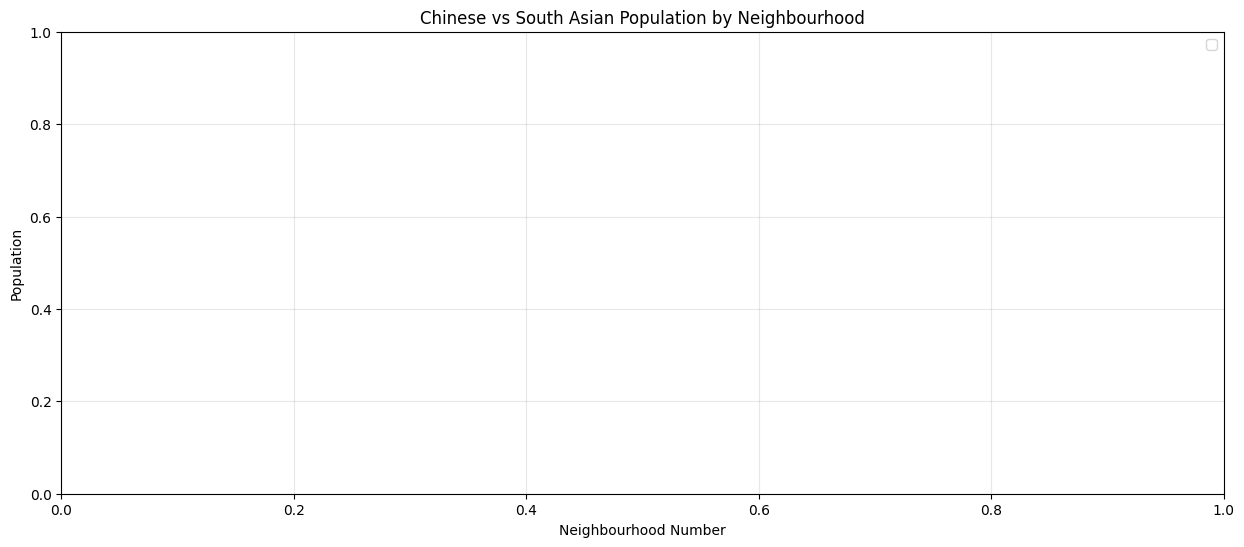

In [ ]:
# Assuming your df is called minority_sum_df
minority_sum_df.iloc[:, 0] = minority_sum_df.iloc[:, 0].astype(str).str.strip()
groups_to_plot = ["Chinese", "South Asian"]

subset = minority_sum_df[minority_sum_df.iloc[:, 1].isin(groups_to_plot)]
print(subset.iloc[:, 0])  # just to confirm you got 2 rows
# Drop the first two columns (index + group name) and the last one if it's "Total"
neigh_cols = minority_sum_df.columns[2:-1]

plt.figure(figsize=(15, 6))

for _, row in subset.iterrows():
    plt.plot(neigh_cols, row[2:-1].astype(float), label=row.iloc[1])

plt.title("Chinese vs South Asian Population by Neighbourhood")
plt.xlabel("Neighbourhood Number")
plt.ylabel("Population")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# 2️⃣ check if “Chinese” or “South Asian” even appear in that column exactly as expected
print(minority_sum_df.iloc[:, 1].unique())


['33300' '28035' '13815' '345' '6125' '2075' '460' '1600' '530' '415'
 '130' '45' '1560' '935' '5265']


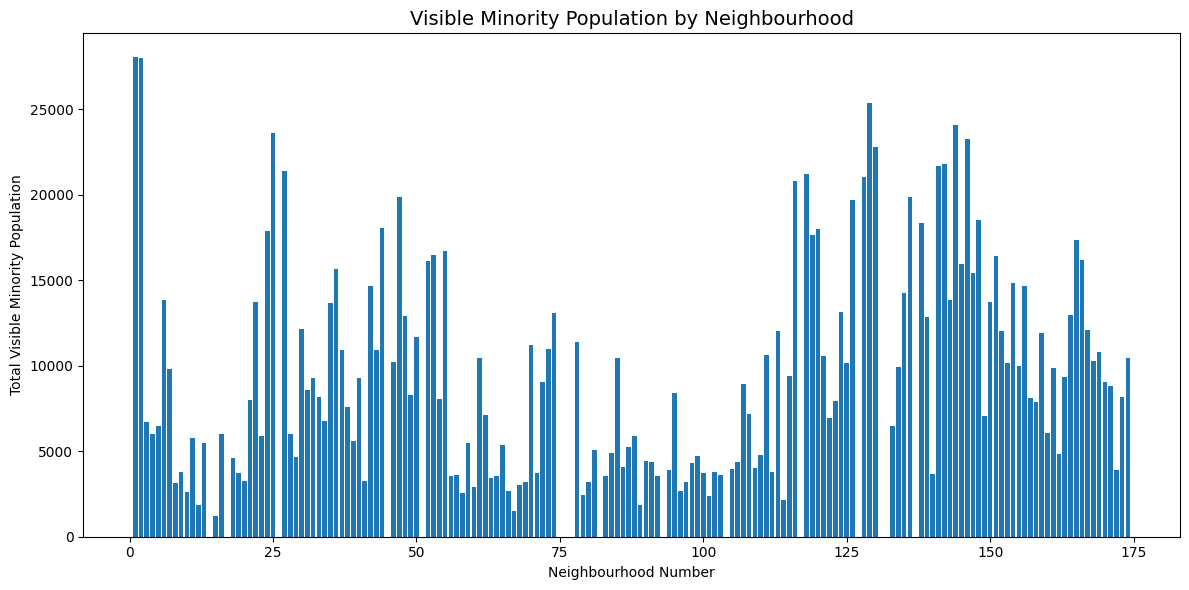

In [ ]:
minority_row = df.iloc[1641]

# Drop the label column (the text one)
minority_row = minority_row.drop(df.columns[0])

# Convert values to numeric
minority_row = pd.to_numeric(minority_row, errors="coerce")

plt.figure(figsize=(12,6))
plt.bar(minority_row.index.astype(int), minority_row.values)

plt.title("Visible Minority Population by Neighbourhood", fontsize=14)
plt.xlabel("Neighbourhood Number")
plt.ylabel("Total Visible Minority Population")
plt.tight_layout()
plt.show()

In [ ]:
minority_row

,1641
1,28035
2,27975
3,6705
4,5985
5,6465
...,...
170,9050
171,8805
172,3900
173,8160


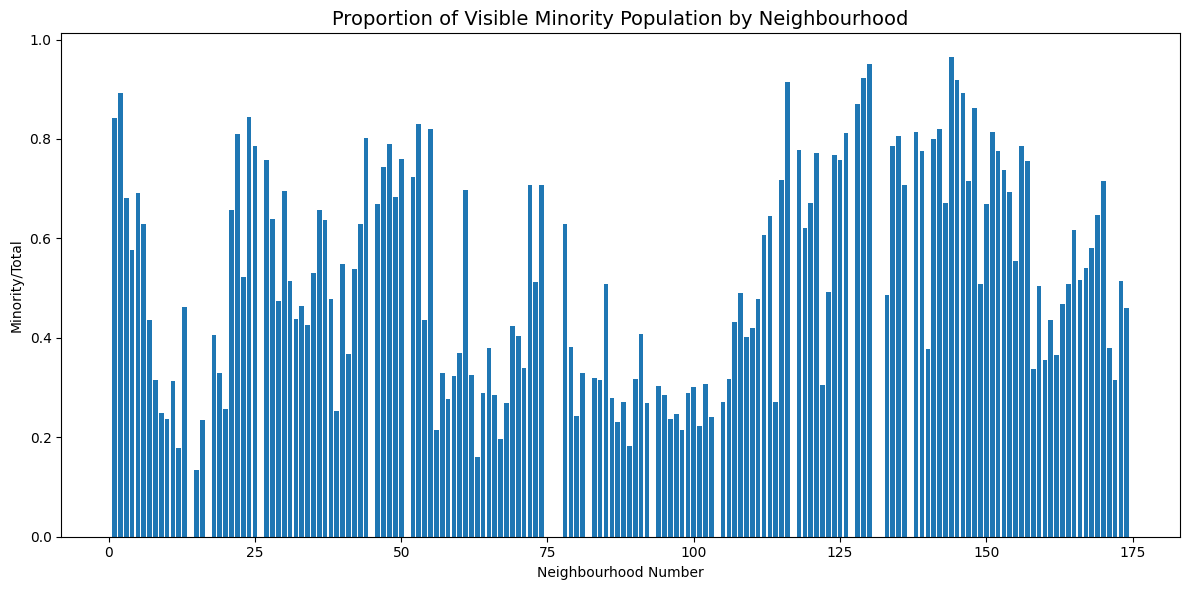

In [ ]:
total_row = df.iloc[1640]
total_row = total_row.drop(df.columns[0])
total_row = pd.to_numeric(total_row, errors="coerce")

# Calculate proportion
proportion = minority_row / total_row

# Plot
plt.figure(figsize=(12,6))
plt.bar(proportion.index.astype(int), proportion.values)

plt.title("Proportion of Visible Minority Population by Neighbourhood", fontsize=14)
plt.xlabel("Neighbourhood Number")
plt.ylabel("Minority/Total")
plt.tight_layout()
plt.show()


This plot shows the percentage of minority people in each neighbourhoods
# Hate crime dataset EDA (A new version that includes the incidents in 2024)

In [ ]:
crimes_df= pd.read_csv("/content/drive/MyDrive/Blogathon 2025/hatecrimes.csv")
crimes_df

,_id,EVENT_UNIQUE_ID,OCCURRENCE_YEAR,OCCURRENCE_DATE,OCCURRENCE_TIME,REPORTED_YEAR,REPORTED_DATE,REPORTED_TIME,DIVISION,LOCATION_TYPE,...,RELIGION_BIAS,SEXUAL_ORIENTATION_BIAS,GENDER_BIAS,MULTIPLE_BIAS,PRIMARY_OFFENCE,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,ARREST_MADE
0,1,GO-2020813480,2014,2014-08-01,1200,2020,2020-04-30,1904,D33,Religious Place of Worship/Cultural Centre,...,Jewish,NaN,NaN,No,Wilful Promotion of Hatred,053,Henry Farm (53),053,Henry Farm (53),No
1,2,GO-2019601581,2016,2016-01-01,900,2019,2019-04-03,1956,D42,"House (Townhouse, Retirement Home, Garage, Veh...",...,NaN,Gay,NaN,No,This should be removed,144,Morningside Heights (144),131,Rouge (131),No
2,3,GO-2019728283,2016,2016-09-01,0,2019,2019-04-23,754,D53,"Educational Institution (Universities, College...",...,NaN,NaN,NaN,No,Assault With a Weapon,173,North Toronto (173),104,Mount Pleasant West (104),No
3,4,GO-2018698451,2017,2017-06-22,824,2018,2018-04-19,1015,D52,Streets/Roadways/Highway,...,NaN,NaN,Woman,No,Assault With a Weapon,164,Wellington Place (164),077,Waterfront Communities-The Island (77),Yes
4,5,GO-2018695170,2017,2017-09-05,900,2018,2018-04-19,1333,D53,"Educational Institution (Universities, College...",...,Jewish,NaN,NaN,No,Mischief Under $5000,099,Mount Pleasant East (99),099,Mount Pleasant East (99),No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800,1801,GO-20242717397,2024,2024-12-16,1541,2024,2024-12-16,1623,D14,Streets/Roadways/Highway,...,NaN,Gay,NaN,No,Assault,080,Palmerston-Little Italy (80),080,Palmerston-Little Italy (80),No
1801,1802,GO-20242736685,2024,2024-12-19,815,2024,2024-12-19,954,D52,Streets/Roadways/Highway,...,Muslim,NaN,NaN,No,Assault,078,Kensington-Chinatown (78),078,Kensington-Chinatown (78),No
1802,1803,GO-20242757429,2024,2024-12-22,620,2024,2024-12-22,1029,D43,"House (Townhouse, Retirement Home, Garage, Veh...",...,Muslim,NaN,NaN,No,Uttering Threats - Bodily Harm,133,Centennial Scarborough (133),133,Centennial Scarborough (133),Yes
1803,1804,GO-20242760247,2024,2024-12-22,1620,2024,2024-12-22,1626,D52,Other Commercial / Corporate Places,...,NaN,2Slgbtq+,NaN,No,Assault,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No


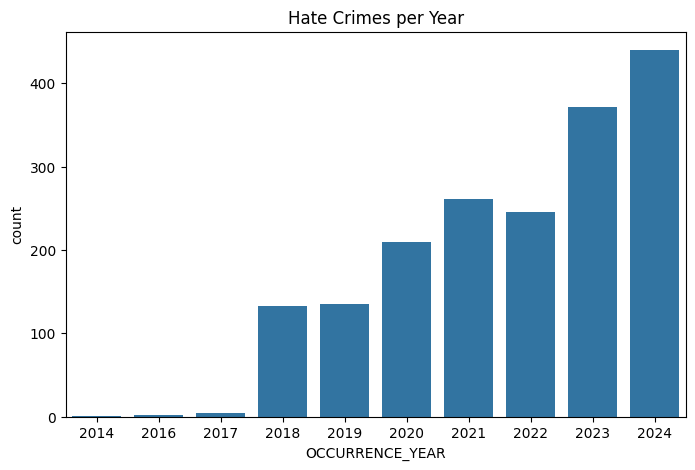

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='OCCURRENCE_YEAR', data=crimes_df)
plt.title('Hate Crimes per Year')
plt.show()

I noticed that 2022 was the only year that has a fewer number of incidents compared to the previous year, may due to various reasions like COVID lockdown, lack of report, etc. We can pay some attention to 2022 if we want to touch the time relationship I think.

In [ ]:
df.isna().sum()

,0
Neighbourhood Number,0
1,0
2,0
3,0
4,0
...,...
170,0
171,0
172,0
173,0


In [ ]:
minority_df.isna().sum()

,0
Neighbourhood Number,0
1,0
2,0
3,0
4,0
...,...
170,0
171,0
172,0
173,0


In [ ]:
crimes_df.isna().sum()

,0
_id,0
EVENT_UNIQUE_ID,0
OCCURRENCE_YEAR,0
OCCURRENCE_DATE,0
OCCURRENCE_TIME,0
REPORTED_YEAR,0
REPORTED_DATE,0
REPORTED_TIME,0
DIVISION,0
LOCATION_TYPE,53


In [ ]:
crimes_df.fillna(crimes_df['LOCATION_TYPE'].mode()[0], inplace = True)
crimes_df.fillna(crimes_df['PRIMARY_OFFENCE'].mode()[0], inplace = True)

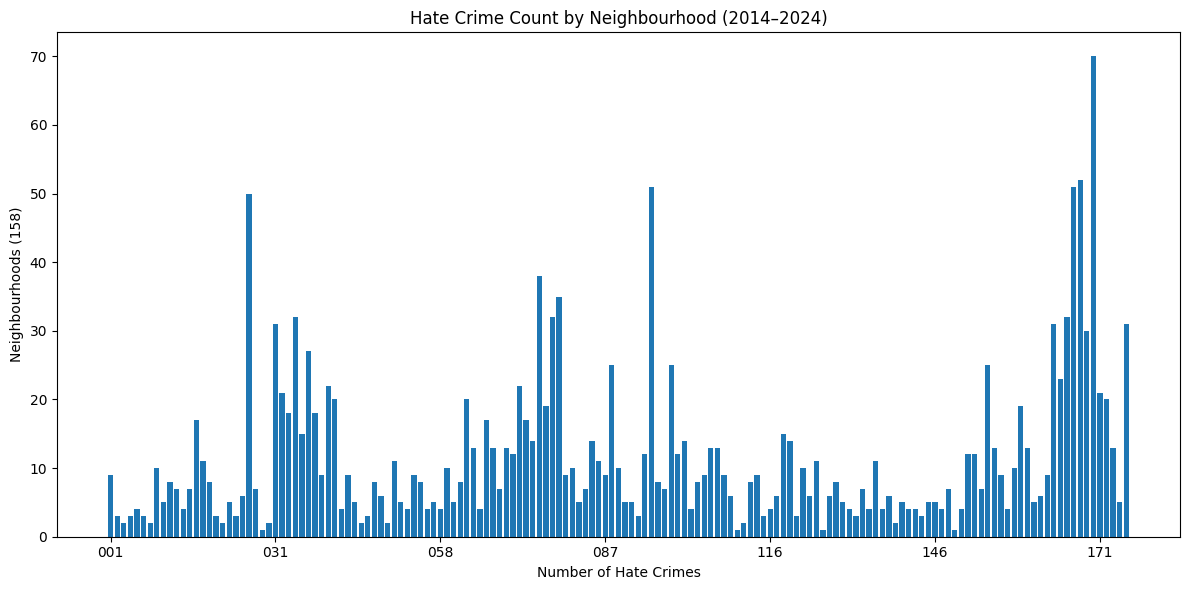

In [ ]:
crime_counts = crimes_df['HOOD_158'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))  # Tall plot to fit all 158 neighbourhoods
plt.bar(crime_counts.index, crime_counts.values)  # horizontal bar for readability
plt.ylabel("Number of Hate Crimes")
plt.xlabel("Neighbourhoods (158)")
plt.title("Hate Crime Count by Neighbourhood (2014–2024)")
plt.xticks(range(0, 175, 25))
plt.tight_layout()
plt.show()


In [ ]:
crimes_df['HOOD_158'].value_counts()

,count
HOOD_158,
170,70
168,52
095,51
167,51
027,50
...,...
030,2
109,1
125,1


# Merging 2 datasets
This part I just tried to convert the type of values to interger in order to merge the number of incidents to the census dataset.

In [ ]:
minority_df['Neighbourhood Number'].dtype

dtype('O')

In [ ]:
crimes_df['HOOD_158'].dtype

dtype('O')

In [ ]:
minority_df['Neighbourhood Number'].dtype

dtype('O')

In [ ]:
crimes_df['HOOD_158'] = crimes_df['HOOD_158'].astype(str).str.lstrip('0')

In [ ]:
 crimes_df['HOOD_158'].value_counts()

,count
HOOD_158,
170,70
168,52
95,51
167,51
27,50
...,...
30,2
109,1
125,1


In [ ]:
crimes_df = crimes_df[crimes_df['HOOD_158'] != 'NSA']

In [ ]:
crime_counts = crimes_df['HOOD_158'].value_counts().sort_index()
crime_counts

,count
HOOD_158,
1,9
10,5
100,14
101,4
102,8
...,...
95,51
96,8
97,7


In [ ]:
minority_df.columns = minority_df.columns.astype(str)
minority_df["Neighbourhood Number"]

,Neighbourhood Number
1640,Total - Visible minority for the population in...
1641,Total visible minority population
1642,South Asian
1643,Chinese
1644,Black
1645,Filipino
1646,Arab
1647,Latin American
1648,Southeast Asian
1649,West Asian


In [ ]:
minority_df= minority_df.T
minority_df

,1640,1641,1642,1643,1644,1645,1646,1647,1648,1649,1650,1651,1652,1653,1654
Neighbourhood Number,Total - Visible minority for the population in...,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority
1,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265
2,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370
3,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150
4,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600
171,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380
172,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485
173,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730


In [ ]:
minority_df.index

Index(['Neighbourhood Number', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '165', '166', '167', '168', '169', '170', '171', '172', '173', '174'],
      dtype='object', length=159)

In [ ]:
minority_df.columns

RangeIndex(start=1640, stop=1655, step=1)

In [ ]:
df1 = minority_df.copy()
df1

,1640,1641,1642,1643,1644,1645,1646,1647,1648,1649,1650,1651,1652,1653,1654
Neighbourhood Number,Total - Visible minority for the population in...,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority
1,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265
2,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370
3,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150
4,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600
171,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380
172,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485
173,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730


In [ ]:
df1.columns = df1.iloc[0]
df1

Neighbourhood Number,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority
Neighbourhood Number,Total - Visible minority for the population in...,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority
1,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265
2,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370
3,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150
4,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600
171,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380
172,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485
173,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730


In [ ]:
df1["Neighbourhood Number"] = minority_df.index
df1 = df1.iloc[1:].reset_index(drop=True)

In [ ]:
df1

Neighbourhood Number,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number
0,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265,1
1,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370,2
2,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150,3
3,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395,4
4,9355,6465,780,130,2830,760,150,890,290,140,110,0,145,245,2890,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600,170
154,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380,171
155,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485,172
156,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730,173


In [ ]:
df1.to_csv('/content/drive/MyDrive/Blogathon 2025/minority.csv', index=False)

In [ ]:
df1['Neighbourhood Number']

,Neighbourhood Number
0,1
1,2
2,3
3,4
4,5
...,...
153,170
154,171
155,172
156,173


In [ ]:
crime_counts_df = crimes_df['HOOD_158'].value_counts().reset_index()
crime_counts_df.columns = ['Neighbourhood Number', 'Crime Count']
crime_counts_df

,Neighbourhood Number,Crime Count
0,170,70
1,168,52
2,95,51
3,167,51
4,27,50
...,...,...
149,30,2
150,109,1
151,125,1
152,29,1


In [ ]:
merged_df = df1.merge(crime_counts_df, on='Neighbourhood Number', how='left')
merged_df['Crime Count'] = merged_df['Crime Count'].fillna(0)
merged_df

,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number,Crime Count
0,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265,1,9.0
1,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370,2,3.0
2,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150,3,0.0
3,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395,4,2.0
4,9355,6465,780,130,2830,760,150,890,290,140,110,0,145,245,2890,5,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600,170,70.0
154,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380,171,21.0
155,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485,172,20.0
156,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730,173,13.0


In [ ]:
merged_df[merged_df['Neighbourhood Number'] == "27"]

,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number,Crime Count
23,28255,21400,4490,1210,5590,3815,300,1730,1750,570,395,45,625,880,6855,27,50.0


In [ ]:
merged_df[merged_df['Crime Count'] == 0]


,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number,Crime Count
2,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150,3,0.0
17,12595,3240,735,460,375,565,135,240,135,60,55,60,250,170,9355,20,0.0
100,6260,3805,425,55,1900,485,55,400,195,40,0,0,150,95,2455,112,0.0
102,7965,2165,280,205,830,240,20,205,20,35,70,45,35,175,5800,114,0.0


### Neighbourhood number 3, 20, 112, 114 has no incidents

In [ ]:
crimes_df[crimes_df['HOOD_158'] =="170"]


,_id,EVENT_UNIQUE_ID,OCCURRENCE_YEAR,OCCURRENCE_DATE,OCCURRENCE_TIME,REPORTED_YEAR,REPORTED_DATE,REPORTED_TIME,DIVISION,LOCATION_TYPE,...,RELIGION_BIAS,SEXUAL_ORIENTATION_BIAS,GENDER_BIAS,MULTIPLE_BIAS,PRIMARY_OFFENCE,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,ARREST_MADE
28,29,GO-2018368358,2018,2018-02-27,943,2018,2018-02-27,951,D52,"Government Building (Courthouse, Museums, Parl...",...,Streets/Roadways/Highway,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Assault,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),Yes
34,35,GO-2018486339,2018,2018-03-16,1800,2018,2018-03-17,1336,D52,"Apartment Building (Condo, Retirement Buidling...",...,Jewish,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Mischief Under $5000,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No
45,46,GO-2018697960,2018,2018-04-16,620,2018,2018-04-19,745,D52,Other Commercial / Corporate Places,...,Streets/Roadways/Highway,Streets/Roadways/Highway,Woman,No,Assault With a Weapon,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),Yes
71,72,GO-20181141157,2018,2018-06-23,746,2018,2018-06-23,746,D52,Public Transportation,...,Jewish,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Mischief Under $5000,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No
158,159,GO-2019462672,2019,2019-03-14,143,2019,2019-03-14,144,D52,Streets/Roadways/Highway,...,Streets/Roadways/Highway,Gay,Streets/Roadways/Highway,No,Assault,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1752,1753,GO-20242344474,2024,2024-10-26,2328,2024,2024-10-26,2328,D52,"Open Area, Park or Parking Lot",...,Jewish,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Mischief Under $5000,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No
1759,1760,GO-20242377410,2024,2024-10-31,1009,2024,2024-10-31,1009,D52,Streets/Roadways/Highway,...,Jewish,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Mischief Under $5000,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No
1772,1773,GO-20242481909,2024,2024-11-14,855,2024,2024-11-14,856,D52,Streets/Roadways/Highway,...,Jewish,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Mischief Under $5000,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No
1793,1794,GO-20242632860,2024,2024-12-05,125,2024,2024-12-05,125,D52,Streets/Roadways/Highway,...,Jewish,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Mischief Under $5000,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No


### 70 rows matches with 70 incidents

In [ ]:
crimes_df[crimes_df['HOOD_158'] =="20"]
# No incidents

,_id,EVENT_UNIQUE_ID,OCCURRENCE_YEAR,OCCURRENCE_DATE,OCCURRENCE_TIME,REPORTED_YEAR,REPORTED_DATE,REPORTED_TIME,DIVISION,LOCATION_TYPE,...,RELIGION_BIAS,SEXUAL_ORIENTATION_BIAS,GENDER_BIAS,MULTIPLE_BIAS,PRIMARY_OFFENCE,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,ARREST_MADE


# Linear regression

In [ ]:
merged_df.columns.tolist()

['Total - Visible minority for the population in private households - 25% sample data',
 '  Total visible minority population',
 '    South Asian',
 '    Chinese',
 '    Black',
 '    Filipino',
 '    Arab',
 '    Latin American',
 '    Southeast Asian',
 '    West Asian',
 '    Korean',
 '    Japanese',
 '    Visible minority, n.i.e.',
 '    Multiple visible minorities',
 '  Not a visible minority',
 'Neighbourhood Number',
 'Crime Count']

In [ ]:
merged_df = merged_df.apply(pd.to_numeric, errors='coerce')

In [ ]:
X = merged_df['  Total visible minority population']
y = merged_df['Crime Count']
X = sm.add_constant(X)
model1 = sm.OLS(y, X).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Crime Count   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.1125
Date:                Thu, 16 Oct 2025   Prob (F-statistic):              0.738
Time:                        03:12:09   Log-Likelihood:                -606.01
No. Observations:                 158   AIC:                             1216.
Df Residuals:                     156   BIC:                             1222.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  10.7564      1.668      6.449      0.000       7.462      14.051
  Total visible minority population  4.846e-05      0.000      0.335      0.738      -0.000       0.000
==============================================================================
Omnibus:                       95.378   Durbin-Watson:                   1.061
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              441.604
Skew:                           2.344   Prob(JB):                     1.28e-96
Kurtosis:                       9.716   Cond. No.                     2.15e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.15e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

From this regression I think the size of a neighbourhood's population does not really matter as the p-value is big and R2 is very small.

In [ ]:
merged_df['Percent Of Minority']= merged_df["  Total visible minority population"]/merged_df['Total - Visible minority for the population in private households - 25% sample data']
merged_df

,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number,Crime Count,Percent Of Minority
0,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265,1,9.0,0.841892
1,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370,2,3.0,0.892487
2,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150,3,0.0,0.680711
3,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395,4,2.0,0.576867
4,9355,6465,780,130,2830,760,150,890,290,140,110,0,145,245,2890,5,3.0,0.691074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600,170,70.0,0.715698
154,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380,171,21.0,0.379853
155,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485,172,20.0,0.315024
156,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730,173,13.0,0.513692


In [ ]:
X2 = merged_df['Percent Of Minority']
X2 = sm.add_constant(X2)
model2  = sm.OLS(y, X2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Crime Count   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.207
Date:                Thu, 16 Oct 2025   Prob (F-statistic):              0.274
Time:                        04:13:50   Log-Likelihood:                -605.46
No. Observations:                 158   AIC:                             1215.
Df Residuals:                     156   BIC:                             1221.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  13.6099      2.345      5.803      0.000       8.978      18.242
Percent Of Minority    -4.5365      4.129     -1.099      0.274     -12.692       3.619
==============================================================================
Omnibus:                       99.300   Durbin-Watson:                   1.093
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              496.846
Skew:                           2.424   Prob(JB):                    1.29e-108
Kurtosis:                      10.209   Cond. No.                         5.94
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

For the above regression, I'm actually not sure (help!!!) The statistic says the percentage of minority community matters when I didn't add a constant but not when I added constant.

In [ ]:
X3 = merged_df["  Not a visible minority"]
X3 = sm.add_constant(X3)
model3 = sm.OLS(y, X3).fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Crime Count   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     19.87
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           1.57e-05
Time:                        03:12:15   Log-Likelihood:                -596.60
No. Observations:                 158   AIC:                             1197.
Df Residuals:                     156   BIC:                             1203.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        3.8545      1.858      2.075      0.040       0.185       7.524
  Not a visible minority     0.0010      0.000      4.458      0.000       0.001       0.001
==============================================================================
Omnibus:                      115.457   Durbin-Watson:                   1.140
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              844.465
Skew:                           2.734   Prob(JB):                    4.23e-184
Kurtosis:                      12.918   Cond. No.                     1.91e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.91e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The above statistic says that p-value is small enough but R2 is very small I dont think it explains much, the coefficient is very close to 0 too.

In [ ]:
merged_df.rename(columns={'Total - Visible minority for the population in private households - 25% sample data': 'Total Population'}, inplace=True)
merged_df

,Total Population,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number,Crime Count,Percent Of Minority
0,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265,1,9.0,0.841892
1,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370,2,3.0,0.892487
2,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150,3,0.0,0.680711
3,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395,4,2.0,0.576867
4,9355,6465,780,130,2830,760,150,890,290,140,110,0,145,245,2890,5,3.0,0.691074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600,170,70.0,0.715698
154,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380,171,21.0,0.379853
155,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485,172,20.0,0.315024
156,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730,173,13.0,0.513692


In [ ]:
X = merged_df[["Total Population","  Total visible minority population", "  Not a visible minority","Percent Of Minority" ]]
y = merged_df['Crime Count']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            Crime Count   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     7.324
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           2.01e-05
Time:                        03:12:18   Log-Likelihood:                -592.23
No. Observations:                 158   AIC:                             1194.
Df Residuals:                     153   BIC:                             1210.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

After doing this, I realized that I consider the number of hate crime incidents in general the whole time in stead of the racial hate crime incidents (which we should pay attention too).

I mean I should have counted only the crimes that has race, religion, language bias instead of counting every incidents (which includes gender, age and sexuality bias too). I'll try to do this properlly tonight or Wednesday.

# Racial hate crime

That is hate crime happened because of race, ethnicity, language or religiton bias in the hate crime dataset



In [ ]:
crimes_df

,_id,EVENT_UNIQUE_ID,OCCURRENCE_YEAR,OCCURRENCE_DATE,OCCURRENCE_TIME,REPORTED_YEAR,REPORTED_DATE,REPORTED_TIME,DIVISION,LOCATION_TYPE,...,RELIGION_BIAS,SEXUAL_ORIENTATION_BIAS,GENDER_BIAS,MULTIPLE_BIAS,PRIMARY_OFFENCE,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,ARREST_MADE
0,1,GO-2020813480,2014,2014-08-01,1200,2020,2020-04-30,1904,D33,Religious Place of Worship/Cultural Centre,...,Jewish,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Wilful Promotion of Hatred,53,Henry Farm (53),053,Henry Farm (53),No
1,2,GO-2019601581,2016,2016-01-01,900,2019,2019-04-03,1956,D42,"House (Townhouse, Retirement Home, Garage, Veh...",...,Streets/Roadways/Highway,Gay,Streets/Roadways/Highway,No,This should be removed,144,Morningside Heights (144),131,Rouge (131),No
2,3,GO-2019728283,2016,2016-09-01,0,2019,2019-04-23,754,D53,"Educational Institution (Universities, College...",...,Streets/Roadways/Highway,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Assault With a Weapon,173,North Toronto (173),104,Mount Pleasant West (104),No
3,4,GO-2018698451,2017,2017-06-22,824,2018,2018-04-19,1015,D52,Streets/Roadways/Highway,...,Streets/Roadways/Highway,Streets/Roadways/Highway,Woman,No,Assault With a Weapon,164,Wellington Place (164),077,Waterfront Communities-The Island (77),Yes
4,5,GO-2018695170,2017,2017-09-05,900,2018,2018-04-19,1333,D53,"Educational Institution (Universities, College...",...,Jewish,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Mischief Under $5000,99,Mount Pleasant East (99),099,Mount Pleasant East (99),No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800,1801,GO-20242717397,2024,2024-12-16,1541,2024,2024-12-16,1623,D14,Streets/Roadways/Highway,...,Streets/Roadways/Highway,Gay,Streets/Roadways/Highway,No,Assault,80,Palmerston-Little Italy (80),080,Palmerston-Little Italy (80),No
1801,1802,GO-20242736685,2024,2024-12-19,815,2024,2024-12-19,954,D52,Streets/Roadways/Highway,...,Muslim,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Assault,78,Kensington-Chinatown (78),078,Kensington-Chinatown (78),No
1802,1803,GO-20242757429,2024,2024-12-22,620,2024,2024-12-22,1029,D43,"House (Townhouse, Retirement Home, Garage, Veh...",...,Muslim,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Uttering Threats - Bodily Harm,133,Centennial Scarborough (133),133,Centennial Scarborough (133),Yes
1803,1804,GO-20242760247,2024,2024-12-22,1620,2024,2024-12-22,1626,D52,Other Commercial / Corporate Places,...,Streets/Roadways/Highway,2Slgbtq+,Streets/Roadways/Highway,No,Assault,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No


In [ ]:
bias_cols = ['RACE_BIAS', 'ETHNICITY_BIAS', 'LANGUAGE_BIAS', 'RELIGION_BIAS']

biased_crimes = crimes_df[bias_cols].apply(lambda row: any(row != 'None'), axis=1)

In [ ]:
biased_count = biased_crimes.sum()
print(f"Total hate crimes with any bias: {biased_count}")

Total hate crimes with any bias: 1774


In [ ]:
racial_df = crimes_df[biased_crimes]
racial_df

,_id,EVENT_UNIQUE_ID,OCCURRENCE_YEAR,OCCURRENCE_DATE,OCCURRENCE_TIME,REPORTED_YEAR,REPORTED_DATE,REPORTED_TIME,DIVISION,LOCATION_TYPE,...,RELIGION_BIAS,SEXUAL_ORIENTATION_BIAS,GENDER_BIAS,MULTIPLE_BIAS,PRIMARY_OFFENCE,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,ARREST_MADE
0,1,GO-2020813480,2014,2014-08-01,1200,2020,2020-04-30,1904,D33,Religious Place of Worship/Cultural Centre,...,Jewish,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Wilful Promotion of Hatred,53,Henry Farm (53),053,Henry Farm (53),No
1,2,GO-2019601581,2016,2016-01-01,900,2019,2019-04-03,1956,D42,"House (Townhouse, Retirement Home, Garage, Veh...",...,Streets/Roadways/Highway,Gay,Streets/Roadways/Highway,No,This should be removed,144,Morningside Heights (144),131,Rouge (131),No
2,3,GO-2019728283,2016,2016-09-01,0,2019,2019-04-23,754,D53,"Educational Institution (Universities, College...",...,Streets/Roadways/Highway,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Assault With a Weapon,173,North Toronto (173),104,Mount Pleasant West (104),No
3,4,GO-2018698451,2017,2017-06-22,824,2018,2018-04-19,1015,D52,Streets/Roadways/Highway,...,Streets/Roadways/Highway,Streets/Roadways/Highway,Woman,No,Assault With a Weapon,164,Wellington Place (164),077,Waterfront Communities-The Island (77),Yes
4,5,GO-2018695170,2017,2017-09-05,900,2018,2018-04-19,1333,D53,"Educational Institution (Universities, College...",...,Jewish,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Mischief Under $5000,99,Mount Pleasant East (99),099,Mount Pleasant East (99),No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800,1801,GO-20242717397,2024,2024-12-16,1541,2024,2024-12-16,1623,D14,Streets/Roadways/Highway,...,Streets/Roadways/Highway,Gay,Streets/Roadways/Highway,No,Assault,80,Palmerston-Little Italy (80),080,Palmerston-Little Italy (80),No
1801,1802,GO-20242736685,2024,2024-12-19,815,2024,2024-12-19,954,D52,Streets/Roadways/Highway,...,Muslim,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Assault,78,Kensington-Chinatown (78),078,Kensington-Chinatown (78),No
1802,1803,GO-20242757429,2024,2024-12-22,620,2024,2024-12-22,1029,D43,"House (Townhouse, Retirement Home, Garage, Veh...",...,Muslim,Streets/Roadways/Highway,Streets/Roadways/Highway,No,Uttering Threats - Bodily Harm,133,Centennial Scarborough (133),133,Centennial Scarborough (133),Yes
1803,1804,GO-20242760247,2024,2024-12-22,1620,2024,2024-12-22,1626,D52,Other Commercial / Corporate Places,...,Streets/Roadways/Highway,2Slgbtq+,Streets/Roadways/Highway,No,Assault,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No


In [ ]:
racial_by_neighbourhood =racial_df['HOOD_158'].value_counts().reset_index()
racial_by_neighbourhood.columns = ['HOOD_158', 'Biased_Crime_Count']

In [ ]:
racial_by_neighbourhood

,HOOD_158,Biased_Crime_Count
0,170,70
1,168,52
2,95,51
3,167,51
4,27,50
...,...,...
149,30,2
150,109,1
151,125,1
152,29,1


I decied to to more linear regression in another colab os it's easier to follow. Please check that one out.